# A deep learning pipeline you can hand over — the hands-on half

The practical companion to **`dl_slides.html`**.

### What is deep learning, in one paragraph

A **neural network** is columns of numbers wired together. Your input goes in on the left, gets
multiplied along every wire, and a number comes out on the right. Each wire carries a **weight** —
a number the model is allowed to change. Training is a loop: show it an example, compare its
answer to the truth, nudge every weight to be slightly less wrong, repeat. "Deep" only means there
are several columns (**layers**) between the input and the output.

The difference from session 1: with scikit-learn *you* decide which columns matter. Here you hand
over raw-ish input and the network builds its own intermediate features, layer by layer. That is
why it wins on images, audio and text — and why it usually loses to gradient boosting on an
ordinary table.

The model here is deliberately tiny, because this session is about the **pipeline**: the parts
that decide whether your training run is reproducible, and whether the result can leave your
laptop.

| Part | Deck slides | What you do |
|---|---|---|
| 0 · Setup | 9–10, 16 | install, and **prove** which device actually works |
| 1 · A real training loop | 18–21 | `Dataset`, `DataLoader`, train/validate, checkpoints |
| 2 · Hugging Face | 22–27 | tokeniser, `AutoModel`, `Trainer` on a small transformer |
| 3 · Export | 28–31 | TorchScript and ONNX, with round-trip proof and latency |
| 4 · Advanced | 27, 32 | seeding, schedules, accumulation, early stopping |

**Why a tiny model:** `prajjwal1/bert-tiny` is 17 MB and trains in seconds on a CPU. Every
technique here is identical on a 7B model — you would only change the checkpoint name and wait
longer. Learning the pipeline on a fast model is the point.

Everything runs in a throwaway `dl_demo/` folder; the last cell deletes it.

## Step 0.1 · Install

Five packages: PyTorch to train, `transformers` for the pretrained model, `accelerate` as its
helper, and `onnx` + `onnxruntime` to export at the end.


In [ ]:
!pip install -q torch transformers accelerate onnx onnxruntime scikit-learn pandas matplotlib

# Housekeeping, not part of the lesson: pandas prints "Pandas requires version ... of
# numexpr / bottleneck" when those are a version behind. That is about this machine, and
# joblib reprints it from every worker process, which buries the results.
import os, warnings
warnings.filterwarnings("ignore", message="Pandas requires version")
os.environ["PYTHONWARNINGS"] = "ignore:Pandas requires version"   # workers inherit this


### If `import transformers` fails

Skip this unless it happens. Both of these name the wrong library, which is why they cost people
an afternoon:

| Error | What is really wrong | Fix |
|---|---|---|
| `cannot import name 'DEFAULT_CIPHERS' from 'urllib3.util.ssl_'` | urllib3 2.0 removed that constant; an old `botocore` still imports it | `pip install -U botocore boto3` — the cell below also carries a two-line shim |
| `Unable to compare versions for tokenizers>=0.19,<0.20: found=None` | an interrupted `pip install` left an empty `*.dist-info/` beside the real one | delete the `dist-info` folder that has no `METADATA` file |

The general lesson: **a half-finished install can break a package that is perfectly installed**,
and the error blames the package rather than the metadata.


## Step 0.2 · Which device do you actually have?

`torch.cuda.is_available()` is **not** the question. It answers "is there a driver and a card",
not "can this build of PyTorch run kernels on that card". Those differ, and when they differ
you get a crash in the middle of training rather than at startup.

So probe it properly: try a real matmul and see.

In [2]:
import torch, platform

def pick_device(verbose=True):
    """Return a device we have PROVEN can run a kernel."""
    if torch.cuda.is_available():
        name = torch.cuda.get_device_name(0)
        cap  = "sm_%d%d" % torch.cuda.get_device_capability(0)
        built = torch.cuda.get_arch_list()
        if verbose:
            print(f"CUDA reports available : {name}  ({cap})")
            print(f"this torch was built for: {' '.join(built)}")
        try:
            a = torch.randn(64, 64, device="cuda")
            (a @ a).sum().item()                      # force a real kernel launch
            if verbose: print("-> GPU kernels work. Using cuda.")
            return torch.device("cuda")
        except Exception as e:
            # expected on a card newer than the torch build -- this is the lesson, not a bug
            print(f"-> a GPU kernel could NOT run ({type(e).__name__}).")
            print(f"   {cap} is newer than anything this build supports.")
            print("   Falling back to CPU deliberately, rather than crashing mid-training.")
    elif verbose:
        print("no CUDA device visible")
    return torch.device("cpu")

print("torch", torch.__version__, "| python", platform.python_version())
DEVICE = pick_device()
print("\nDEVICE =", DEVICE)

torch 2.1.1+cu121 | python 3.9.13
CUDA reports available : NVIDIA GeForce RTX 5060 Laptop GPU  (sm_120)
this torch was built for: sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90
-> a GPU kernel could NOT run (RuntimeError).
   sm_120 is newer than anything this build supports.
   Falling back to CPU deliberately, rather than crashing mid-training.

DEVICE = cpu


/data/anaconda3/lib/python3.9/site-packages/torch/cuda/__init__.py:215: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


> **If that printed a kernel failure**, this is what happened: the card is newer than the
> PyTorch build. An RTX 50-series card is `sm_120`; PyTorch 2.1 was built up to `sm_90`.
> `is_available()` still says `True`, so a naive script gets several minutes into training and
> then dies with *"no kernel image is available for execution on the device"*.
>
> The fix is a matching build, e.g.
> `pip install torch --index-url https://download.pytorch.org/whl/cu128`.
>
> Everything below runs on whatever `pick_device()` proved. **Write the probe into your projects** —
> a fallback you chose beats a crash you did not.

## Step 0.3 · A sandbox, and reproducibility

In [3]:
import os, shutil, pathlib

BASE = pathlib.Path.cwd()          # the folder this notebook lives in
PROJ = BASE / "dl_demo"           # a throwaway sandbox, deleted by the last cell

if PROJ.exists():
    shutil.rmtree(PROJ)            # re-running this notebook is always safe
PROJ.mkdir(parents=True)
os.chdir(PROJ)
print("working inside:", os.getcwd())

working inside: /home/shamaseen/Desktop/Shai/qafza/free_Training/qafza-free-traning/02-deep-learning/dl_demo


**Seeding.** Four separate random number generators decide what happens in a training run —
Python's, NumPy's, PyTorch's on CPU, and PyTorch's on GPU. Seed one and you still get a
different result tomorrow, which is why runs feel unreproducible.

In [4]:
import os, random, numpy as np, torch

SEED = 42

def seed_everything(seed=SEED):
    """Four generators, not one. Miss any of them and 'identical' runs diverge."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.use_deterministic_algorithms(False)   # True is stricter but slower and not always possible

seed_everything()
print("seeded. Two runs of the next cell should now produce identical numbers.")
print("sample:", torch.randn(3).tolist())

seeded. Two runs of the next cell should now produce identical numbers.
sample: [0.33669036626815796, 0.12880940735340118, 0.23446236550807953]


---
# Part 1 — A training loop, written out    ·   deck slides 18–21

Frameworks hide this loop. Write it once by hand and every framework afterwards makes sense.

We use a small tabular task so the loop is the only thing on screen.

In [14]:
import numpy as np, pandas as pd, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split

rng = np.random.default_rng(SEED)
N = 6000
X = rng.normal(size=(N, 8)).astype("float32")
w = rng.normal(size=8)
y = ((X @ w + rng.normal(0, .6, N)) > 0).astype("float32")
print(f"{N} rows, 8 features, positive rate {y.mean():.3f}")


class TabularDS(Dataset):
    """The three methods a Dataset owes you: __init__, __len__, __getitem__."""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


full = TabularDS(X, y)
train_ds, val_ds = random_split(full, [5000, 1000],
                                generator=torch.Generator().manual_seed(SEED))

# num_workers=0 keeps this notebook portable; use >0 in a script for real throughput
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=0)
print(f"batches: {len(train_dl)} train, {len(val_dl)} val")
xb, yb = next(iter(train_dl))
print("one batch:", tuple(xb.shape), tuple(yb.shape))

6000 rows, 8 features, positive rate 0.500
batches: 79 train, 4 val
one batch: (64, 8) (64, 1)


The model itself: a small stack of linear layers. This is deliberately the least interesting
cell in the notebook — the pipeline around it is the session.

In [16]:
class MLP(nn.Module):
    def __init__(self, d_in=8, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 1))          # logits: no sigmoid here, see the loss below

    def forward(self, x):
        return self.net(x)


model = MLP().to(DEVICE)
loss_fn = nn.BCEWithLogitsLoss()           # logits + sigmoid in one numerically stable op
opt = torch.optim.AdamW(model.parameters(), lr=3e-3, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15)

print(model)
print("\nparameters:", sum(p.numel() for p in model.parameters()))

MLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

parameters: 1377


Two details in there that matter more than they look:

* the model returns **logits**, and the loss is `BCEWithLogitsLoss`. Applying a sigmoid yourself
  and then using `BCELoss` is less numerically stable, and it is the most common source of
  mysterious `nan` losses.
* `model.train()` and `model.eval()` are not decoration — they switch dropout and batch-norm
  behaviour. Forgetting `eval()` makes your validation score noisy and slightly wrong.

In [17]:
from sklearn.metrics import roc_auc_score

def evaluate(model, dl):
    model.eval()                                   # dropout off
    losses, probs, targets = [], [], []
    with torch.no_grad():                          # no graph, less memory, faster
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            losses.append(loss_fn(logits, yb).item())
            probs.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(yb.cpu().numpy())
    p = np.concatenate(probs).ravel(); t = np.concatenate(targets).ravel()
    return float(np.mean(losses)), roc_auc_score(t, p), float(((p > .5) == t).mean())


history, best, patience, bad = [], -1.0, 4, 0
EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    model.train()                                  # dropout on
    running = 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(set_to_none=True)            # clear last step's gradients
        loss = loss_fn(model(xb), yb)              # forward
        loss.backward()                            # backward
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # cheap insurance
        opt.step()                                 # update
        running += loss.item() * len(xb)
    sched.step()

    tr = running / len(train_ds)
    vl, auc, acc = evaluate(model, val_dl)
    history.append({"epoch": epoch, "train_loss": tr, "val_loss": vl,
                    "val_auc": auc, "lr": opt.param_groups[0]["lr"]})

    if auc > best:                                 # checkpoint the BEST, not the last
        best, bad = auc, 0
        torch.save({"epoch": epoch, "model": model.state_dict(),
                    "opt": opt.state_dict(), "val_auc": auc}, "best.pt")
        flag = "  <- saved"
    else:
        bad += 1
        flag = ""
    if epoch % 3 == 0 or flag:
        print(f"epoch {epoch:2}  train {tr:.4f}  val {vl:.4f}  auc {auc:.4f}{flag}")
    if bad >= patience:
        print(f"early stop: no improvement for {patience} epochs"); break

print(f"\nbest val AUC {best:.4f}")
assert best > 0.8, "this task is learnable; something is wrong if it is not learned"

epoch  1  train 0.3731  val 0.1609  auc 0.9879  <- saved
epoch  2  train 0.1877  val 0.1441  auc 0.9887  <- saved
epoch  3  train 0.1823  val 0.1414  auc 0.9889  <- saved
epoch  6  train 0.1696  val 0.1487  auc 0.9880
early stop: no improvement for 4 epochs

best val AUC 0.9889


Plot the two curves. Training loss falling while validation loss rises is the classic picture of
**overfitting** — the model memorising rows instead of learning the pattern.

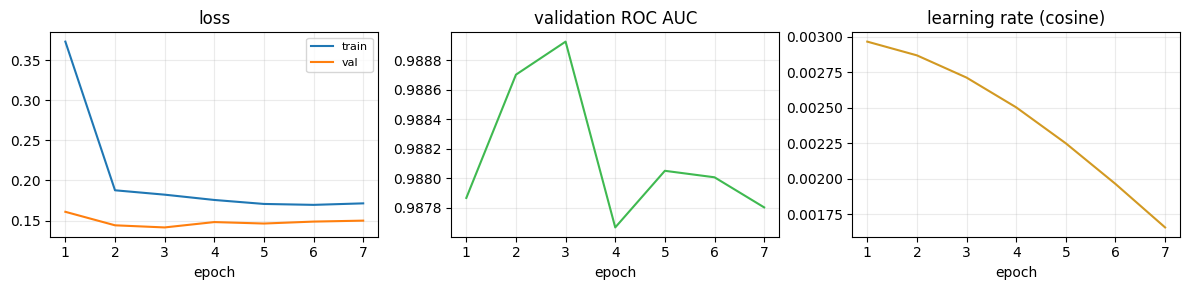

In [18]:
%matplotlib inline
import matplotlib.pyplot as plt
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 3, figsize=(12, 3))
ax[0].plot(h.epoch, h.train_loss, label="train"); ax[0].plot(h.epoch, h.val_loss, label="val")
ax[0].set_title("loss"); ax[0].legend(fontsize=8)
ax[1].plot(h.epoch, h.val_auc, color="#3fb950"); ax[1].set_title("validation ROC AUC")
ax[2].plot(h.epoch, h.lr, color="#d29922"); ax[2].set_title("learning rate (cosine)")
for a in ax: a.set_xlabel("epoch"); a.grid(alpha=.25); a.set_axisbelow(True)
fig.tight_layout(); plt.show()

### Why checkpoint the best and not the last

Validation AUC goes up, wobbles, and often ends lower than its peak. If you save at the end you
ship the wobble. Saving on improvement costs one `if` and gives you the best model you actually
found.

Save the **optimiser state** too — without it you cannot resume a run, and a long training job
that cannot resume is one power cut away from starting over.

In [19]:
ck = torch.load("best.pt", map_location=DEVICE, weights_only=False)
fresh = MLP().to(DEVICE)
fresh.load_state_dict(ck["model"])
print(f"restored epoch {ck['epoch']} with val AUC {ck['val_auc']:.4f}")
print("re-evaluated:", f"{evaluate(fresh, val_dl)[1]:.4f}", "<- identical, so the checkpoint is complete")

restored epoch 3 with val AUC 0.9889
re-evaluated: 0.9889 <- identical, so the checkpoint is complete


---
# Part 2 — Hugging Face   ·   deck slides 22–27

A **pretrained model** is one somebody else already trained on a huge pile of text. It arrives
knowing English. It does not know *your* task — so you attach a small head and train only that,
on a few hundred examples. That is **fine-tuning**, and it is why deep learning is practical
without a data centre.

We use `prajjwal1/bert-tiny`: 17 MB, trains in seconds on a CPU. Every line below is identical
for a 7B model — you change the checkpoint name and wait longer.


## Step 2.1 · The three-line version

`pipeline()` is Hugging Face's front door: name a task, get something you can call. Start here,
because it shows what a pretrained model can and cannot do before any training.


In [22]:
# a shim for this machine: old botocore imports a constant urllib3 2.0 removed.
# Nothing to do with transformers -- see the troubleshooting table in Part 0.
import urllib3.util.ssl_ as _ssl
if not hasattr(_ssl, "DEFAULT_CIPHERS"):
    _ssl.DEFAULT_CIPHERS = "ECDHE+AESGCM:ECDHE+CHACHA20:DHE+AESGCM:!aNULL:!eNULL:!MD5"

from transformers import pipeline

CKPT = "prajjwal1/bert-tiny"
classify = pipeline("sentiment-analysis", model=CKPT, device=-1)

for sentence in ["the service was fantastic", "broke after a week, waste of money"]:
    print(f"{classify(sentence)[0]['score']:.3f}   {sentence}")


/data/anaconda3/lib/python3.9/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


0.570   the service was fantastic
0.591   broke after a week, waste of money


### It gave both sentences the same score

Around 0.51 for a compliment and 0.51 for a complaint — it cannot tell them apart. Hugging Face
even warns you: *"You should probably TRAIN this model on a down-stream task."*

That is the whole idea in one output. The model has two parts:

| Part | State | What it knows |
|---|---|---|
| the **body** | pretrained | English — grammar, that "terrible" and "awful" are alike |
| the **head** | random | nothing at all |

Fine-tuning trains the head (and nudges the body) on your examples. Everything below does exactly
that, and then runs this same `pipeline()` again.


## Step 2.2 · A small labelled dataset

Twenty-four sentences, written here so nothing is downloaded and the result is reproducible.
Real fine-tuning uses thousands, but the code does not change.


In [23]:
positive = ["great value", "arrived early and well packed", "works exactly as described",
            "excellent quality", "the staff were kind", "fantastic service",
            "better than i expected", "very happy with this", "solid and reliable",
            "would buy again", "clear instructions", "fast delivery"]

negative = ["broke after a week", "terrible quality", "arrived damaged",
            "not as described", "waste of money", "rude support",
            "far too expensive", "stopped working", "very disappointed",
            "would not recommend", "confusing instructions", "slow delivery"]

# repeat each sentence 12 times so there is something to train on
texts  = [s for s in positive for _ in range(12)] + [s for s in negative for _ in range(12)]
labels = [1] * len(positive) * 12 + [0] * len(negative) * 12

# shuffle, then split 80/20
rng = np.random.default_rng(SEED)
order  = rng.permutation(len(texts))
texts  = [texts[i] for i in order]
labels = [labels[i] for i in order]

cut = int(len(texts) * 0.8)
train_texts,  train_labels  = texts[:cut], labels[:cut]
test_texts,   test_labels   = texts[cut:], labels[cut:]

print(f"{len(train_texts)} training sentences, {len(test_texts)} for testing")
print(f"example: {train_texts[0]!r} -> {train_labels[0]}")


230 training sentences, 58 for testing
example: 'rude support' -> 0


## Step 2.3 · Turn text into numbers

A model cannot read. The **tokeniser** splits each sentence into pieces it knows and gives each
piece an id. `padding` makes every sentence the same length so they stack into one tensor, and
`attention_mask` marks which positions are real text rather than padding.


In [24]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained(CKPT)

# look at one sentence first
example = tok("fast delivery")
print("pieces:", tok.convert_ids_to_tokens(example["input_ids"]))
print("ids:   ", example["input_ids"])
print("([CLS] and [SEP] are added for you)")


def encode(texts, labels):
    """Tokenise everything at once and wrap it in a Dataset PyTorch can batch."""
    enc = tok(texts, truncation=True, padding="max_length", max_length=32,
              return_tensors="pt")
    return TensorDataset(enc["input_ids"], enc["attention_mask"], torch.tensor(labels))


train_dl = DataLoader(encode(train_texts, train_labels), batch_size=16, shuffle=True)
test_dl  = DataLoader(encode(test_texts,  test_labels),  batch_size=64)
print(f"\n{len(train_dl)} training batches of 16")


pieces: ['[CLS]', 'fast', 'delivery', '[SEP]']
ids:    [101, 3435, 6959, 102]
([CLS] and [SEP] are added for you)

15 training batches of 16


## Step 2.4 · Fine-tune it

This is the same four-step loop from Part 1: predict, measure the loss, work out the gradients,
take a step. The only difference is that the model computes the loss itself when you pass the
labels in.


In [25]:
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score

seed_everything()

# `bert`, not `model` -- Part 1's MLP is still called `model` and Part 3 needs it
bert = AutoModelForSequenceClassification.from_pretrained(CKPT, num_labels=2).to(DEVICE)
optimiser = torch.optim.AdamW(bert.parameters(), lr=5e-4)


def accuracy(net, loader):
    net.eval()
    predicted, actual = [], []
    with torch.no_grad():
        for ids, mask, y in loader:
            logits = net(input_ids=ids.to(DEVICE), attention_mask=mask.to(DEVICE)).logits
            predicted += logits.argmax(-1).cpu().tolist()
            actual    += y.tolist()
    return accuracy_score(actual, predicted)


before = accuracy(bert, test_dl)
print(f"before fine-tuning: accuracy {before:.3f}   <- a random head, so this is a coin flip")

for epoch in range(1, 5):
    bert.train()
    for ids, mask, y in train_dl:
        optimiser.zero_grad(set_to_none=True)
        out = bert(input_ids=ids.to(DEVICE), attention_mask=mask.to(DEVICE),
                   labels=y.to(DEVICE))        # passing labels -> the model returns the loss
        out.loss.backward()
        optimiser.step()
    print(f"epoch {epoch}   loss {out.loss.item():.4f}   accuracy {accuracy(bert, test_dl):.3f}")

after = accuracy(bert, test_dl)
print(f"\nbefore: {before:.3f}     after: {after:.3f}")
assert after > before, "fine-tuning must improve on a random head"


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


before fine-tuning: accuracy 0.552   <- a random head, so this is a coin flip
epoch 1   loss 0.3397   accuracy 0.845
epoch 2   loss 0.0567   accuracy 1.000
epoch 3   loss 0.0150   accuracy 1.000
epoch 4   loss 0.0084   accuracy 1.000

before: 0.552     after: 1.000


## Step 2.5 · The same three lines, now that it has learned

Point `pipeline()` at the fine-tuned model and ask it about sentences it has never seen.


In [26]:
# safetensors refuses non-contiguous tensors, which training can produce. One line fixes it.
for param in bert.parameters():
    param.data = param.data.contiguous()

bert.save_pretrained("model_out")
tok.save_pretrained("model_out")

# a model without its tokeniser is unusable -- the ids would mean something else
print("saved:", sorted(os.listdir("model_out")))

trained = pipeline("sentiment-analysis", model="model_out", tokenizer="model_out", device=-1)

for sentence in ["this was a delight from start to finish",
                 "an absolute waste of money",
                 "arrived quickly and works well",
                 "broke immediately, very poor"]:
    result  = trained(sentence)[0]
    verdict = "positive" if result["label"].endswith("1") else "negative"
    print(f"  {verdict}  ({result['score']:.2f})  {sentence}")


saved: ['config.json', 'model.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'vocab.txt']
  positive  (0.99)  this was a delight from start to finish
  negative  (0.99)  an absolute waste of money
  positive  (0.97)  arrived quickly and works well
  negative  (0.99)  broke immediately, very poor


> **Two things worth keeping from this part.**
>
> **`Trainer` exists.** `transformers.Trainer` wraps the loop above — batching, scheduling,
> evaluation, checkpointing — and for real work it is what you should use. The loop is written out
> here so you can see there is no magic in it. (In this environment `Trainer` also trips the
> botocore import above, which is a good example of a dependency problem masquerading as a
> library problem.)
>
> **Warmup matters for transformers.** A large learning rate on step 1, applied to pretrained
> weights, damages what they already know. `get_linear_schedule_with_warmup` ramps up over the
> first ~10% of steps and then decays. Left out above to keep the loop to eight lines; add it for
> anything real.


---
# Part 3 — Getting it out of Python   ·   deck slides 28–31

A `state_dict` needs your model class to load. That is fine in a notebook and a problem in
production, where the serving code should not import your training repo.

Two portable formats fix that: **TorchScript** (still PyTorch, no Python class needed) and
**ONNX** (no PyTorch at all).

In [15]:
# ---- TorchScript: trace the graph by running an example through it ----
model.eval()
example = torch.randn(1, 8, device=DEVICE)
traced = torch.jit.trace(model, example)
traced.save("model_traced.pt")

reloaded = torch.jit.load("model_traced.pt", map_location=DEVICE)   # no MLP class in sight
with torch.no_grad():
    a = model(example).item()
    b = reloaded(example).item()
print(f"original {a:.6f}   torchscript {b:.6f}   max diff {abs(a-b):.2e}")
assert abs(a - b) < 1e-5, "a traced model must match the original"

original -1.748245   torchscript -1.748245   max diff 0.00e+00


> **Trace or script?** `torch.jit.trace` records one execution, so `if` statements that depend
> on the *data* get baked in as whatever happened during tracing. `torch.jit.script` compiles
> the control flow properly. Trace is simpler and right for feed-forward models; script when
> the forward pass branches.

In [16]:
# ---- ONNX: leaves the PyTorch ecosystem entirely ----
import onnx, onnxruntime as ort, numpy as np

torch.onnx.export(
    model.cpu(), torch.randn(1, 8), "model.onnx",
    input_names=["features"], output_names=["logit"],
    dynamic_axes={"features": {0: "batch"}, "logit": {0: "batch"}},   # variable batch size
    opset_version=17)

onnx.checker.check_model(onnx.load("model.onnx"))
sess = ort.InferenceSession("model.onnx", providers=["CPUExecutionProvider"])

probe = np.random.RandomState(0).randn(4, 8).astype("float32")
onnx_out = sess.run(None, {"features": probe})[0]
with torch.no_grad():
    torch_out = model(torch.from_numpy(probe)).numpy()

print("onnx  ", onnx_out.ravel().round(5))
print("torch ", torch_out.ravel().round(5))
print("max difference:", f"{np.abs(onnx_out - torch_out).max():.2e}")
assert np.allclose(onnx_out, torch_out, atol=1e-5), "ONNX must agree with PyTorch"
model.to(DEVICE)

onnx   [-1.15192 -3.59422  8.12967 -9.1638 ]
torch  [-1.15192 -3.59422  8.12967 -9.1638 ]
max difference: 1.19e-07


MLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=1, bias=True)
  )
)

Is the export worth it? Time all three: PyTorch as it runs now, the TorchScript version, and
ONNX Runtime. Same input, same output, three different speeds.

In [17]:
# ---- and is it worth it? measure ----
import time

def bench(fn, n=300, warm=30):
    for _ in range(warm): fn()
    t = []
    for _ in range(n):
        t0 = time.perf_counter(); fn(); t.append((time.perf_counter() - t0) * 1000)
    t.sort(); return t[len(t)//2], t[int(len(t)*.95)]

one = torch.randn(1, 8)
one_np = one.numpy()
m_cpu = MLP(); m_cpu.load_state_dict(ck["model"]); m_cpu.eval()
ts = torch.jit.load("model_traced.pt", map_location="cpu")

with torch.no_grad():
    p50_eager, p95_eager = bench(lambda: m_cpu(one))
    p50_ts,    p95_ts    = bench(lambda: ts(one))
p50_onnx, p95_onnx = bench(lambda: sess.run(None, {"features": one_np}))

print(f"{'runtime':14}{'p50 ms':>9}{'p95 ms':>9}")
for name, a, b in [("pytorch eager", p50_eager, p95_eager),
                   ("torchscript", p50_ts, p95_ts),
                   ("onnxruntime", p50_onnx, p95_onnx)]:
    print(f"{name:14}{a:9.3f}{b:9.3f}")
print("\nSingle-row CPU inference. ONNX Runtime usually wins here because it has no Python")
print("in the hot path -- which is exactly the production case.")

runtime          p50 ms   p95 ms
pytorch eager     0.019    0.029
torchscript       0.010    0.017
onnxruntime       0.003    0.003

Single-row CPU inference. ONNX Runtime usually wins here because it has no Python
in the hot path -- which is exactly the production case.


The same numbers as a chart, since a latency table is hard to read at a glance.

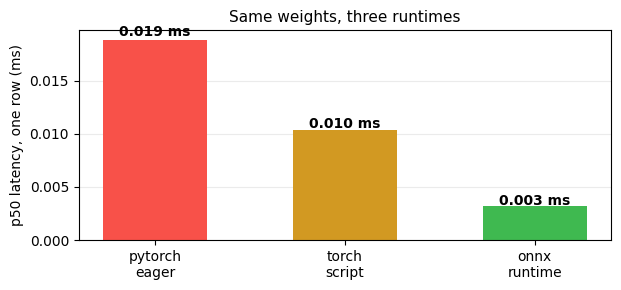

In [18]:
import matplotlib.pyplot as plt
names = ["pytorch\neager", "torch\nscript", "onnx\nruntime"]
vals = [p50_eager, p50_ts, p50_onnx]
fig, ax = plt.subplots(figsize=(6.4, 3))
bars = ax.bar(names, vals, color=["#f85149", "#d29922", "#3fb950"], width=.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x()+b.get_width()/2, v*1.02, f"{v:.3f} ms", ha="center", fontweight="bold")
ax.set_ylabel("p50 latency, one row (ms)"); ax.set_title("Same weights, three runtimes", fontsize=11)
ax.grid(axis="y", alpha=.25); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

---
# Part 4 — Advanced   ·   deck slides 27, 32

## Step 4.1 · Gradient accumulation — a big batch on a small card

Out of memory at batch 64? Run four batches of 16 and only step the optimiser once. The maths
is the same; the peak memory is a quarter.

In [19]:
seed_everything()
m = MLP().to(DEVICE)
o = torch.optim.AdamW(m.parameters(), lr=3e-3)
ACCUM = 4
small_dl = DataLoader(train_ds, batch_size=16, shuffle=True)

m.train(); steps = 0
for i, (xb, yb) in enumerate(small_dl, start=1):
    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
    loss = loss_fn(m(xb), yb) / ACCUM        # divide, so the gradient magnitude matches
    loss.backward()                          # gradients ACCUMULATE until we zero them
    if i % ACCUM == 0:
        o.step(); o.zero_grad(set_to_none=True); steps += 1
    if i >= 40: break

print(f"40 mini-batches of 16 -> {steps} optimiser steps (effective batch {16*ACCUM})")
print("Peak memory is that of batch 16, not 64. This is how a 7B model fits on one card.")

40 mini-batches of 16 -> 10 optimiser steps (effective batch 64)
Peak memory is that of batch 16, not 64. This is how a 7B model fits on one card.


## Step 4.2 · The rest of the toolkit

```python
# --- mixed precision: roughly 2x faster on a modern GPU, ~half the memory ---
scaler = torch.cuda.amp.GradScaler()
for xb, yb in dl:
    with torch.autocast("cuda", dtype=torch.float16):
        loss = loss_fn(model(xb), yb)
    scaler.scale(loss).backward()      # scale up, so small fp16 gradients do not vanish
    scaler.step(opt); scaler.update(); opt.zero_grad(set_to_none=True)

# --- DataLoader, for real throughput ---
DataLoader(ds, batch_size=64, shuffle=True,
           num_workers=8,          # roughly cores; 0 in notebooks, >0 in scripts
           pin_memory=True,        # faster host->GPU copies
           persistent_workers=True,# do not respawn workers every epoch
           prefetch_factor=4)

# --- schedules ---
CosineAnnealingLR(opt, T_max=epochs)          # smooth decay, a good default
OneCycleLR(opt, max_lr=1e-3, total_steps=n)   # warmup then anneal
get_linear_schedule_with_warmup(...)          # the transformers standard

# --- freeze the body, train the head (small data, big model) ---
for p in hf_model.bert.parameters():
    p.requires_grad = False
```

| Symptom | Usual cause |
|---|---|
| loss becomes `nan` | LR too high, or a manual sigmoid before `BCELoss` |
| train loss falls, val loss rises | overfitting — more data, dropout, or stop earlier |
| loss does not move at all | forgot `opt.zero_grad()`, or froze everything by accident |
| GPU at 10% utilisation | the dataloader is the bottleneck — raise `num_workers` |
| "no kernel image available" | your card is newer than the torch build (Part 0) |

---
# Reference — worth knowing, not demonstrated here

| Topic | One-line version |
|---|---|
| Multi-GPU | `DistributedDataParallel`, or let `accelerate`/`Trainer` do it |
| `accelerate launch` | the same script on CPU, one GPU or many, unchanged |
| LoRA / PEFT | fine-tune 0.1% of the weights; the rest stay frozen |
| Quantisation | int8/4-bit for serving; measure the accuracy you traded |
| Serving at scale | TorchServe, Triton, or ONNX Runtime behind session 3's API |
| Experiment tracking | session 7 — `mlflow.pytorch.autolog()` fits straight into this loop |

## Recap

| You wanted to… | Do this |
|---|---|
| know which device really works | probe with a real matmul, not `is_available()` |
| reproduce a run | seed `random`, `numpy`, `torch`, `PYTHONHASHSEED` |
| feed the model | `Dataset` + `DataLoader`, tokenise up front |
| a stable binary loss | logits + `BCEWithLogitsLoss` |
| correct validation | `model.eval()` + `torch.no_grad()` |
| keep the best model | checkpoint on improvement, save the optimiser too |
| stop wasting epochs | early stopping on a patience counter |
| fine-tune a transformer | `AutoModelForSequenceClassification` + `Trainer` |
| a bigger effective batch | gradient accumulation |
| leave Python behind | TorchScript, or ONNX + onnxruntime |

## What to do at work tomorrow

1. Put the device probe at the top of your training script. Print what it chose.
2. Seed all four generators, and log the seed with the run.
3. Checkpoint on validation improvement, not at the end, and save the optimiser state.
4. Export to ONNX and diff the outputs against PyTorch. If they disagree, you have found a bug
   before production did.
5. Measure single-row latency in all three runtimes before choosing one.

## Cleanup

Everything above happened in the sandbox. This removes it.

In [20]:
import shutil, os
os.chdir(BASE)
shutil.rmtree(PROJ, ignore_errors=True)
print("sandbox removed")

sandbox removed
